In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from PIL import Image
import cv2
from scipy import ndimage

# Ćwiczenie 5. 
### Napisz skrypt w Pythonie/Matlabie umożliwiający wczytywanie i wizualizację badanych obrazów.

In [2]:
def crop_image(image: Image, x_start: int, y_start: int, width: int, height: int)-> Image:
    return image.crop((x_start, y_start, x_start + width, y_start + height))

def plot_row(image: Image, row: int) -> plt.Figure:
    img_array = np.array(image)
    y = img_array[row]
    x = np.arange(len(y))
    fig, ax = plt.subplots(figsize=(12, 12))
    sns.lineplot(x=x, y=y, ax=ax)
    return fig

def plot_column(image: Image, column: int) -> plt.Figure:
    img_array = np.array(image)
    y = img_array[::-1, column] # reverse the order of rows to plot from top to bottom
    x = np.arange(len(y))
    fig, ax = plt.subplots(figsize=(12, 12))
    sns.lineplot(x=x, y=y, ax=ax)
    return fig

def save_image(image: Image, filename: str) -> None:
    image.save(filename)

In [3]:
def create_image_widget(image: Image = None, filename: str = "") -> None:
    if image is None and filename:
        image = Image.open(filename)

  
    out = widgets.Output() 

    x_start = widgets.BoundedIntText(
        value=0,
        min=0,
        max=image.width - 1, 
        step=1,
        description='X Start:',
        layout=widgets.Layout(width='200px')
    )
    width = widgets.BoundedIntText(
        value= image.width - 1,
        min=0,
        max=image.width - 1,
        step=1,
        description='Width:',
        layout=widgets.Layout(width='200px')
    )

    y_start = widgets.BoundedIntText(
        value=0,
        min=0,
        max=image.height - 1, 
        step=1,
        description='Y Start:',
        layout=widgets.Layout(width='200px')
    )
    height = widgets.BoundedIntText(
        value= image.height - 1,
        min=0,
        max=image.height - 1,
        step=1,
        description='Height:',
        layout=widgets.Layout(width='200px')
    )

    filename_input = widgets.Text(
        value='cropped_image.tif',
        description='Filename:',
        layout=widgets.Layout(width='200px')
    )

    row = widgets.BoundedIntText(
        value= 0,
        min=0,
        max=image.width - 1,
        step=1,
        description='Row:',
        layout=widgets.Layout(width='200px')
    )

    column = widgets.BoundedIntText(
        value= 0,
        min=0,
        max=image.height - 1,
        step=1,
        description='Column:',
        layout=widgets.Layout(width='200px')
    )

    mode=widgets.Dropdown(
        options=["Image", "Plot row", "Plot column"],
        value="Image",
        description="Display:",
    )

    #assign button widgets
    btn_update = widgets.Button(description='Update', button_style='info')
    btn_save = widgets.Button(description='Save', button_style='info')

    cropped_image = image
    #define button click events
    def update_plot():
        nonlocal cropped_image
        with out:
            clear_output(wait=True) 
            if mode.value == "Image":
                cropped_image = crop_image(image, x_start.value, y_start.value, width.value, height.value)
                display(cropped_image)
            elif mode.value == "Plot row":
                fig = plot_row(cropped_image, row.value)
                display(fig)
                plt.close(fig)

            elif mode.value == "Plot column":
                fig = plot_column(cropped_image, column.value)
                display(fig)
                plt.close(fig)
                

    def btn_update_clicked(b):
        update_plot()

    def btn_save_clicked(b):
        save_image(cropped_image, "results/" + filename_input.value)
        print("Signals saved to:", "results/" + filename_input.value)

    #assign button click events
    btn_update.on_click(btn_update_clicked)
    btn_save.on_click(btn_save_clicked)

    #display widgets
    controls_box = widgets.HBox([btn_update, btn_save, x_start, y_start, width, height, filename_input, mode, row, column],layout=widgets.Layout(flex_flow='row wrap', align_items='center'))

    display(controls_box, out)

    #inital update to display the widget
    update_plot()

In [4]:
create_image_widget(filename="data/chest-xray.tif")

Output()

# Ćwiczenie 6. 
### Zaobserwuj działanie następujących przekształceń punktowych naprzykładowych obrazach.

In [5]:
# multiply by constant
def multiply_by_constant(image: Image, constant: float) -> Image:
    img_array = np.array(image)
    modified_array = img_array * constant
    modified_array = np.clip(modified_array, 0, 255)  # Ensure values are in valid range
    modified_image = Image.fromarray(modified_array.astype('uint8'))
    return modified_image

In [6]:
img = Image.open("data/chest-xray.tif")
create_image_widget(image=multiply_by_constant(img,10))

Output()

In [7]:
def logarithmic_transformation(image: Image, c: float = 255) -> Image:
    """T(r) = c · log(1 + r), the literal equation constant."""
    img_array = np.array(image).astype(np.float64)
    modified_array = c * np.log1p(img_array)
    modified_array = np.clip(modified_array, 0, 255) 
    modified_image = Image.fromarray(modified_array.astype('uint8'))
    return modified_image

In [8]:
img = Image.open("data/spectrum.tif")
create_image_widget(image=logarithmic_transformation(img, c=1000))

Output()

In [9]:
#brightness below m -> will be pushed down towards 0, above m will be pushed up towards 255, m = midpoint intensity, e = slope/contrast strength
def contrast_transformation(image: Image, m: float = 128, e: float = 4) -> Image:
    img_array = np.array(image).astype(np.float64)
    # avoid division by zero
    eps = 1e-6
    safe_r = np.where(img_array == 0, eps, img_array)

    modified_array = 1.0 / (1.0 + (m / safe_r) ** e)
    modified_array = modified_array * 255          # scale [0,1] -> [0,255]
    modified_array = np.clip(modified_array, 0, 255)
    return Image.fromarray(modified_array.astype('uint8'))

In [191]:
img = Image.open("data/chest-xray.tif")
create_image_widget(image=contrast_transformation(img, 50, 2))

Output()

In [ ]:

#higher gamma values will darken the image, while lower values will brighten it. The constant c can be used to scale the output intensity range.
def gamma_correction(image: Image, gamma: float, c: float = 255) -> Image:
    img_array = np.array(image).astype(np.float64)
    normalized_array = img_array / 255.0
    modified_array = np.power(normalized_array, gamma) * c
    modified_array = np.clip(modified_array, 0, 255)
    return Image.fromarray(modified_array.astype('uint8'))

In [12]:
img = Image.open("data/aerial_view.tif")
create_image_widget(image=gamma_correction(img, 10, c=128))

Output()

# Ćwiczenie 7. 
### Wypróbuj działanie wyrównywania histogramu na przykładowych obrazach.

In [23]:
def plot_histogram(image: Image, ignore_zeroes: bool = False, threshold: tuple = None) -> plt.Figure:
    #flatten to 1D array for histogram plotting ([[1, 2 ,3], [4,5,6],[7,8,9]] to [1, 2 ,3, 4,5,6,7,8,9])
    img_array = np.array(image).flatten()
    if ignore_zeroes:
        img_array = img_array[img_array != 0]
    if threshold is not None:
        img_array = img_array[(img_array >= threshold[0]) & (img_array <= threshold[1])]
    sns.histplot(img_array, bins=np.unique(img_array).size, kde=False) 

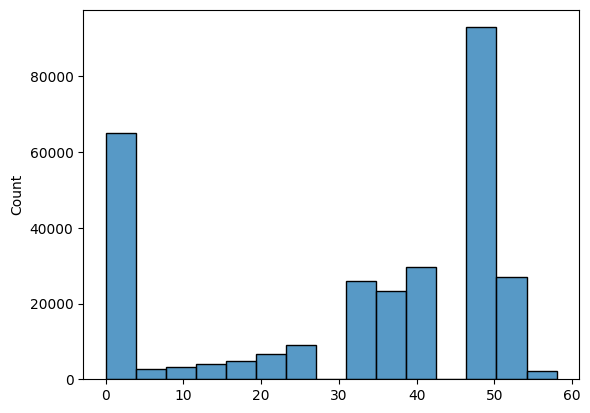

In [24]:
img = Image.open("data/chest-xray.tif")
plot_histogram(img)

In [25]:
def equalize_img(image: Image) -> Image:
    img_eq = cv2.equalizeHist(np.array(image, dtype=np.uint8))
    return Image.fromarray(img_eq, mode='L')

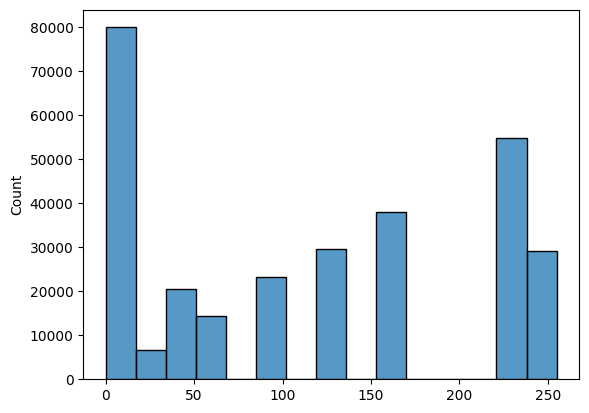

In [28]:
img_eq = equalize_img(img)
plot_histogram(img_eq)


In [29]:
create_image_widget(image=img)

Output()

In [30]:
create_image_widget(image=img_eq)

Output()

# Ćwiczenie 8. 
### Sprawdź działanie lokalnych kontekstowych omówionych na wykładzie pt. „Transformacje poziomu jasności” 

In [31]:
def equalize_img_locally(image: Image, clipLimit: float, tileGridSize: tuple) -> Image:
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    img_eq = clahe.apply(np.array(image, dtype=np.uint8))
    return Image.fromarray(img_eq, mode='L')

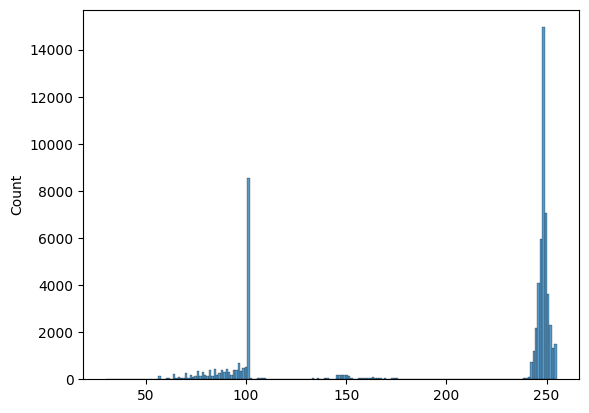

In [32]:
img = Image.open("data/hidden-symbols.tif")
img_eq = equalize_img_locally(img, clipLimit=100.0, tileGridSize=(16,16))
plot_histogram(img_eq)

In [33]:
create_image_widget(image=img)

Output()

In [34]:
create_image_widget(image=img_eq)

Output()

In [36]:
def enhance_image_locally(image: Image, c: float = 22.8 ,
                          k0: float = 0.0, 
                          k1: float = 0.1, 
                          k2: float =0.0, 
                          k3: float = 0.1,
                          size: int = 3) -> Image:
    """Enhance the image locally based on local mean and standard deviation.
       Multiplies a pixel by `c` only where the local neighborhood is both dark
       and low-contrast (i.e. its local mean and local std fall within the given
       fractions of the global statistics); all other pixels are left unchanged.

       Parameters:
       - image: Input grayscale PIL image to be enhanced.
       - c: Enhancement constant (gain) applied to qualifying pixels.
       - k0, k1: Lower/upper bounds for local mean as fractions of the global mean
              (pixel qualifies if k0*m_G <= m_L <= k1*m_G).
       - k2, k3: Lower/upper bounds for local std as fractions of the global std
              (pixel qualifies if k2*sigma_G <= sigma_L <= k3*sigma_G).
       - size: Size of the local neighborhood window (default 3 for 3x3).

    Returns:
    - Enhanced image as a PIL Image object."""
    f = np.array(image, dtype=np.float64)

    mean_local = cv2.blur(f, (size, size))
    mean_sq    = cv2.blur(f**2, (size, size))
    std_local  = np.sqrt(np.maximum(mean_sq - mean_local**2, 0))

    m_G = f.mean()
    sigma_G = f.std()

    mask = (mean_local >= k0 * m_G) & (mean_local <= k1 * m_G) & \
           (std_local  >= k2 * sigma_G) & (std_local <= k3 * sigma_G)

    enhanced = np.where(mask, c * f, f)
    enhanced = np.clip(enhanced, 0, 255)
    return Image.fromarray(enhanced.astype('uint8'))

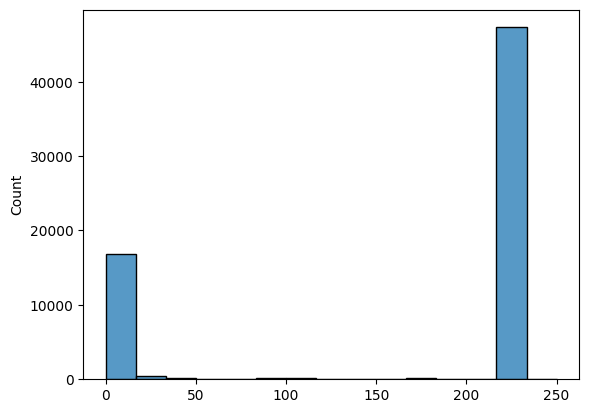

In [38]:
img_eq = enhance_image_locally(img)
plot_histogram(img_eq)

In [39]:
create_image_widget(image=img_eq)

Output()

# Ćwiczenie 9. 
### Zbadaj skuteczność redukcji szumu typu „sól i pieprz”

In [41]:
def linear_avg_filter(image: Image, kernel_size: int) -> Image:
    avraged = cv2.blur(np.array(image), (kernel_size, kernel_size))
    return Image.fromarray(avraged.astype('uint8'))

In [42]:
img = Image.open("data/cboard_salt_pepper.tif")
create_image_widget(img)

Output()

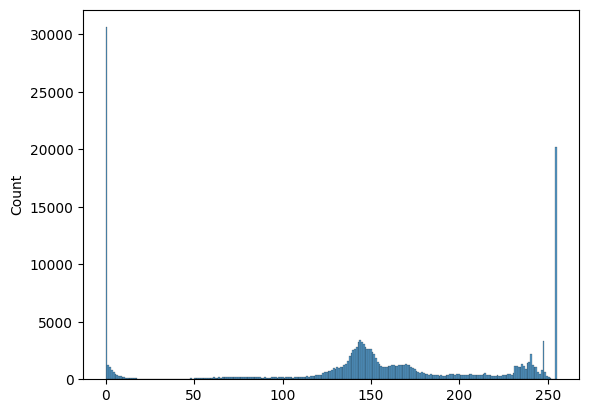

In [43]:
plot_histogram(img)

In [ ]:
img_filtered = linear_avg_filter(img, kernel_size=5)
create_image_widget(img_filtered)

Output()

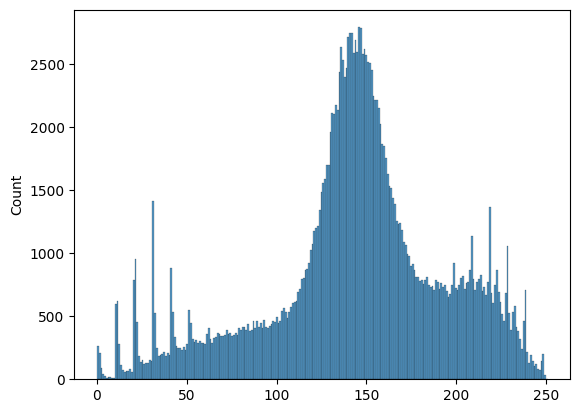

In [49]:
plot_histogram(img_filtered)

In [51]:
def median_filter(image: Image, kernel_size: int) -> Image:
    medianed = cv2.medianBlur(np.array(image), kernel_size)
    return Image.fromarray(medianed.astype('uint8'))

In [52]:
img_filtered = median_filter(img, kernel_size=3)
create_image_widget(img_filtered)

Output()

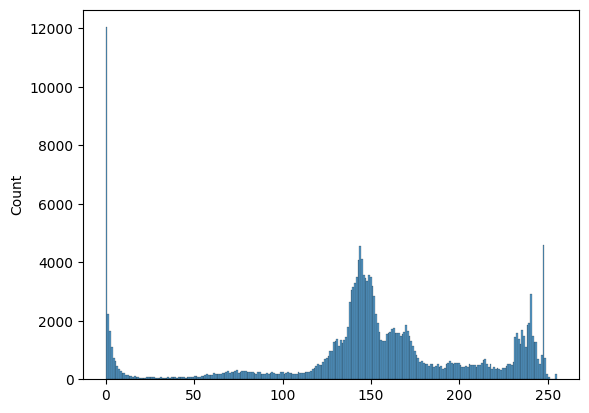

In [54]:
plot_histogram(img_filtered)

In [56]:
def min_filter(image: Image, kernel_size: int) -> Image:
    min_filtered = ndimage.minimum_filter(np.array(image), size=kernel_size)
    return Image.fromarray(min_filtered.astype('uint8'))

In [57]:
img_filtered = min_filter(img, kernel_size=3)
create_image_widget(img_filtered)

Output()

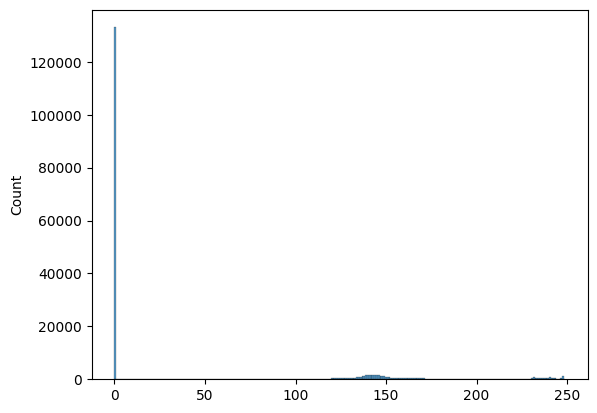

In [58]:
plot_histogram(img_filtered)

In [59]:
def max_filter(image: Image, kernel_size: int) -> Image:
    max_filtered = ndimage.maximum_filter(np.array(image), size=kernel_size)
    return Image.fromarray(max_filtered.astype('uint8'))

In [60]:
img_filtered = max_filter(img, kernel_size=3)
create_image_widget(img_filtered)

Output()

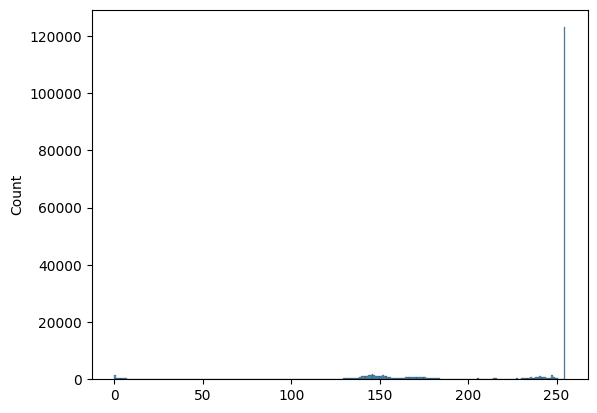

In [61]:
plot_histogram(img_filtered)

# Ćwiczenie 10. 
Zbadaj działanie dolnoprzepustowych filtrów uśredniającego i gaussowskiego dla danych obrazów.

In [63]:
img = Image.open("data/characters_test_pattern.tif")
create_image_widget(img)

Output()

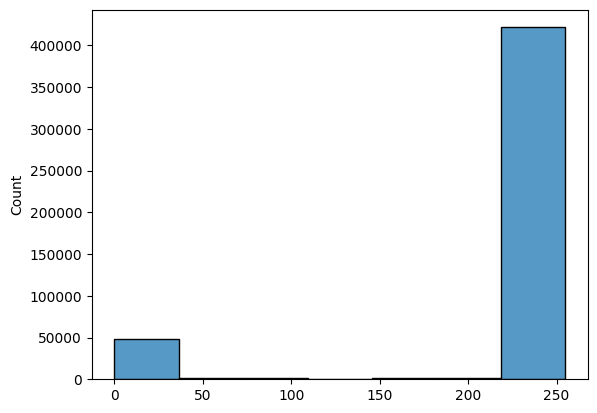

In [64]:
plot_histogram(img)

In [65]:
filtered_avg = linear_avg_filter(img, kernel_size=5)
create_image_widget(filtered_avg)

Output()

In [62]:
def gaussian_filter(image: Image, kernel_size: int) -> Image:
    gaussian_filtered = cv2.GaussianBlur(np.array(image), (kernel_size, kernel_size), sigmaX=0) # sigmaX=0 means that the function will calculate the sigma based on the kernel size.
    return Image.fromarray(gaussian_filtered.astype('uint8'))

In [66]:
filtered_gaussian = gaussian_filter(img, kernel_size=5)
create_image_widget(filtered_gaussian)

Output()

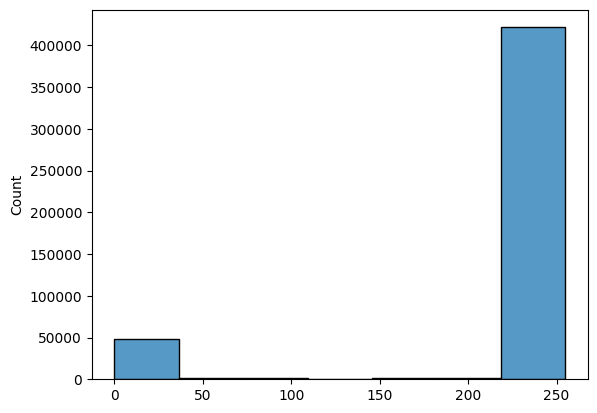

In [67]:
plot_histogram(img)

# Ćwiczenie 11. 
### Wykrywanie krawędzi obiektów i poprawa ostrośc

In [68]:
img = Image.open("data/circuitmask.tif")
create_image_widget(img)

Output()

In [ ]:
def sobel_column_filter(image: Image.Image) -> Image.Image:
    arr = np.array(image.convert('L')) 
    sobel_x = cv2.Sobel(arr, cv2.CV_64F, 1, 0, ksize=3) # use built in sobel kernel for column detection
    sobel_x = np.abs(sobel_x)
    sobel_x = (sobel_x / sobel_x.max() * 255).astype(np.uint8)
    return Image.fromarray(sobel_x.astype('uint8'))

In [ ]:
filtered_img = sobel_column_filter(img)
create_image_widget(filtered_img)

Output()

In [ ]:
def sobel_row_filter(image: Image) -> Image:
    arr = np.array(image.convert('L')) 
    sobel_y = cv2.Sobel(arr, cv2.CV_64F, 0, 1, ksize=3) # use built in sobel kernel for row detection
    sobel_y = np.abs(sobel_y)
    sobel_y = (sobel_y / sobel_y.max() * 255).astype(np.uint8)
    return Image.fromarray(sobel_y.astype('uint8'))

In [102]:
filtered_img = sobel_row_filter(img)
create_image_widget(filtered_img)

Output()

In [99]:
def sobel_magnitude_filter(image: Image) -> Image: # can dtect diagonal edges
    arr = np.array(image.convert('L'))
    sobel_x = cv2.Sobel(arr, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(arr, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = cv2.magnitude(sobel_x, sobel_y)
    magnitude = np.abs(magnitude)
    magnitude = (magnitude / magnitude.max() * 255).astype(np.uint8)
    return Image.fromarray(magnitude.astype('uint8'))

In [100]:
filtered_img = sobel_magnitude_filter(img)
create_image_widget(filtered_img)

Output()

In [97]:
def sobel_diagonal_left_right_filter(image: Image) -> Image:
    arr = np.array(image.convert('L'))
    k_diag1 = np.array([[ 0,  1,  2],
                        [-1,  0,  1],
                        [-2, -1,  0]], dtype=np.float64)
    sobel_diag_lr = cv2.filter2D(arr, cv2.CV_64F, k_diag1)
    sobel_diag_lr = np.abs(sobel_diag_lr)
    sobel_diag_lr = (sobel_diag_lr / sobel_diag_lr.max() * 255).astype(np.uint8)
    return Image.fromarray(sobel_diag_lr.astype('uint8'))

In [98]:
filtered_img = sobel_diagonal_left_right_filter(img)
create_image_widget(filtered_img)

Output()

In [95]:
def sobel_diagonal_right_left_filter(image: Image) -> Image:
    arr = np.array(image.convert('L'))
    k_diag2 = np.array([[-2, -1,  0],
                    [-1,  0,  1],
                    [ 0,  1,  2]], dtype=np.float64)
    sobel_diag_rl = cv2.filter2D(arr, cv2.CV_64F, k_diag2)
    sobel_diag_rl = np.abs(sobel_diag_rl)
    sobel_diag_rl = (sobel_diag_rl / sobel_diag_rl.max() * 255).astype(np.uint8) 
    return Image.fromarray(sobel_diag_rl.astype('uint8'))

In [96]:
filtered_img = sobel_diagonal_right_left_filter(img)
create_image_widget(filtered_img)

Output()

In [228]:
img = Image.open("data/blurry-moon.tif")
create_image_widget(img)

Output()

In [229]:
def laplacian_filter(image: Image) -> Image:
    arr = np.array(image.convert('L'))
    laplacian = cv2.Laplacian(arr, cv2.CV_64F)
    laplacian = np.abs(laplacian)
    laplacian = (laplacian / laplacian.max() * 255).astype(np.uint8)
    return Image.fromarray(laplacian.astype('uint8'))

In [230]:
filtered_img = laplacian_filter(img)
create_image_widget(filtered_img)

Output()

In [231]:
def laplacian_sharpen(image: Image.Image) -> Image.Image:
    arr = np.array(image.convert('L'), dtype=np.float64)
    laplacian = cv2.Laplacian(arr, cv2.CV_64F)
    sharpened = arr - laplacian               
    sharpened = np.clip(sharpened, 0, 255)
    return Image.fromarray(sharpened.astype('uint8'))

In [232]:
filtered_img = laplacian_sharpen(img)
create_image_widget(filtered_img)
 

Output()

In [117]:
img = Image.open("data/text-dipxe-blurred.tif")
create_image_widget(img)

Output()

In [131]:
def unsharp_masking(image: Image, amount: float) -> Image:
    arr = np.array(image, dtype=np.float64)
    blurred = cv2.GaussianBlur(arr, (3, 3), sigmaX=0)
    unsharp_mask = arr - blurred                    
    sharpened = arr + amount * unsharp_mask
    sharpened = np.clip(sharpened, 0, 255)
    return Image.fromarray(sharpened.astype('uint8'))

In [132]:
filtered_img = unsharp_masking(img, amount=1.0) # amount = 1 : normal nsharp masking
create_image_widget(filtered_img)

Output()

In [133]:
filtered_img = unsharp_masking(img, amount=30) # amount > 1 : normal high boost
create_image_widget(filtered_img)

Output()

# Ćwiczenie 12. 

In [196]:
img = Image.open("data/bonescan.tif")
create_image_widget(img)

Output()

In [222]:
img_transformed = gamma_correction(img, 0.5, c=200)
create_image_widget(img_transformed)
# img_transformed = contrast_transformation(img, 40, 3)
# create_image_widget(img_transformed)


Output()

In [223]:
img_equalised = equalize_img_locally(img_transformed, clipLimit=5.0, tileGridSize=(3,3))
create_image_widget(img_equalised)

Output()

In [233]:
sharpened_img = laplacian_sharpen(img_equalised)
create_image_widget(sharpened_img)

Output()

In [236]:
filtered_img = median_filter(sharpened_img, kernel_size=9)
create_image_widget(filtered_img)

Output()

On ma u sibie na wykłądzie tak "ładniejsza" ja robiłe mtutaj na czuja zeby mozna było powiedziec ze cos poekperymentowalismy 